In [1]:
import numpy as np
import bayesflow as bf
from pathlib import Path

from benchmark.examples.diffusion.simulators.rdm_4 import RDM

INFO:bayesflow:Using backend 'tensorflow'


In [2]:
np.random.seed(2026)

In [3]:
simulators = [
    RDM(model="m0", keep_params=False),
    RDM(model="m1", keep_params=False),
    RDM(model="m2", keep_params=False),
    RDM(model="m3", keep_params=False),
]

In [4]:
# Each trial contains signed RT and condition: (batch_size, 384, 2).
adapter = (
    bf.adapters.Adapter()
    .as_set(["rt", "conditions"])
    .concatenate(["rt", "conditions"], into="summary_variables")
    .convert_dtype("float64", "float32")
    .rename("model_indices", "inference_variables")
)

In [5]:
workflow = bf.ModelComparisonWorkflow(
    simulator=simulators,
    adapter=adapter,
    summary_network=bf.networks.DeepSet(summary_dim=12),
    scoring_rules="cross_entropy",
    model_names=["M0", "M1", "M2", "M3"],
    initial_learning_rate=1e-3,
)

In [6]:
val_data = workflow.simulate(1000)

In [7]:
history = workflow.fit_online(
    epochs=200, num_batches_per_epoch=64, batch_size=256, validation_data=val_data
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 454ms/step - ScoringRuleNetwork/scoring_rule: 1.3980 - loss: 1.3980 - val_ScoringRuleNetwork/scoring_rule: 1.3431 - val_loss: 1.3431
Epoch 2/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 864ms/step - ScoringRuleNetwork/scoring_rule: 1.1972 - loss: 1.1972 - val_ScoringRuleNetwork/scoring_rule: 1.0230 - val_loss: 1.0230
Epoch 3/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 60s 941ms/step - ScoringRuleNetwork/scoring_rule: 1.0460 - loss: 1.0460 - val_ScoringRuleNetwork/scoring_rule: 1.0001 - val_loss: 1.0001
Epoch 4/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 911ms/step - ScoringRuleNetwork/scoring_rule: 1.0178 - loss: 1.0178 - val_ScoringRuleNetwork/scoring_rule: 0.9921 - val_loss: 0.9921
Epoch 5/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 954ms/step - ScoringRuleNetwork/scoring_rule: 0.9779 - loss: 0.9779 - val_ScoringRuleNetwork/scoring_rule: 0.9478 - val_loss: 0.9478
Epoch 6/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - ScoringRuleNetwork/scoring_rule: 0.8776 - loss: 0.8776 - val_Scorin

INFO:bayesflow:Training completed in 3.16 hours.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimating completed in 4.72 seconds.


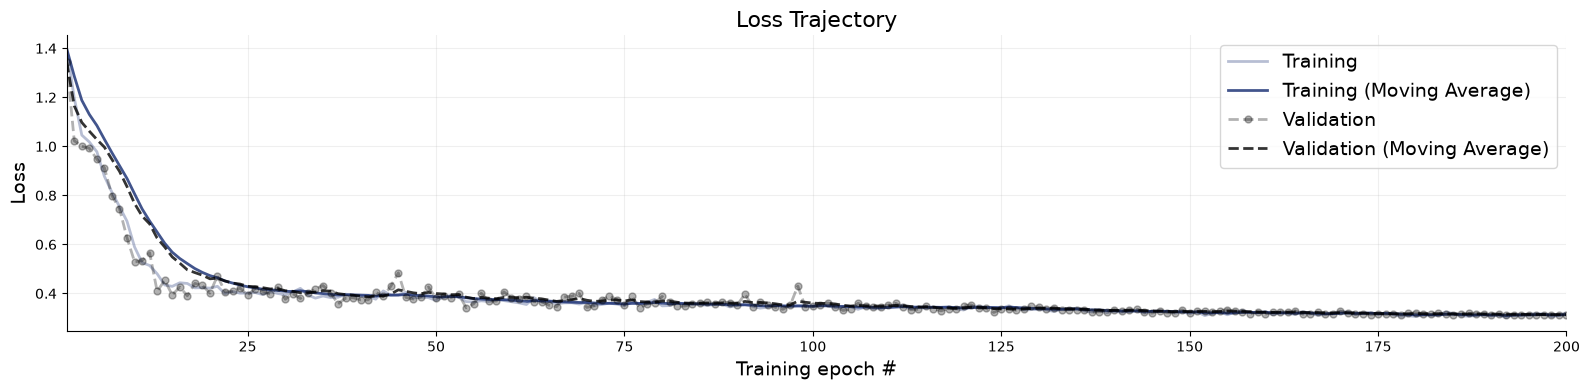

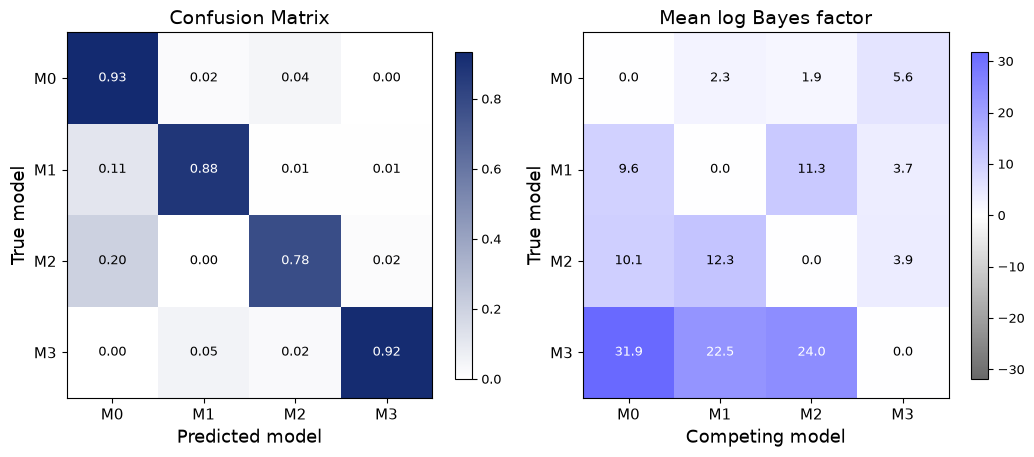

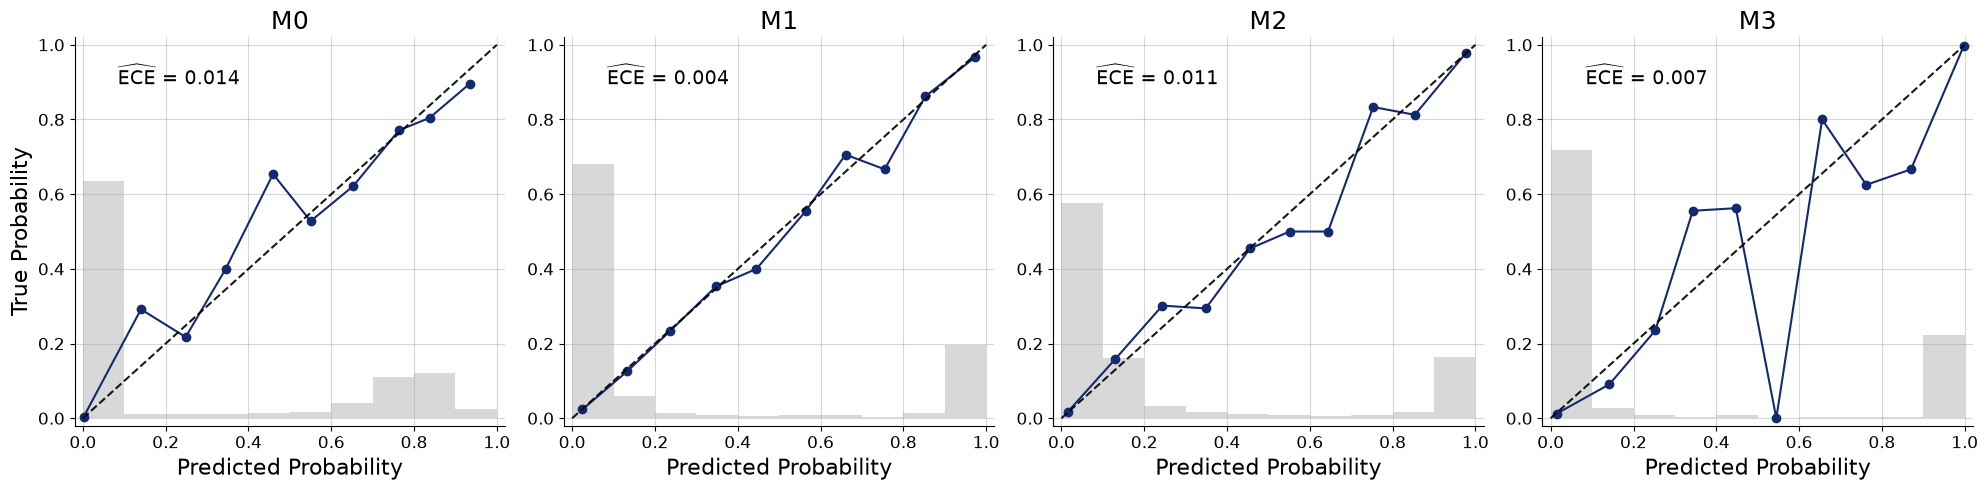

In [8]:
figures = workflow.plot_default_diagnostics(test_data=2000)

In [9]:
# Save the trained approximator
filepath = Path(
    "/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/approximators/trained/direct/direct_cent.keras"
)
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

In [10]:
# Evaluate the saved checkpoint on the shared indirect benchmark.
from benchmark.examples.diffusion.analysis.direct_calibration import (
    ensure_direct_pmp_thresholds,
)
from benchmark.examples.diffusion.analysis.direct_diagnostics import (
    ensure_direct_diagnostics,
)

LOSS = "cross_entropy"
thresholds = ensure_direct_pmp_thresholds(LOSS, checkpoint=filepath)
diagnostics = ensure_direct_diagnostics(LOSS, checkpoint=filepath, indirect_tag="S4D")
print(
    f"Saved {len(thresholds)} threshold rows and {len(diagnostics)} observed diagnostic rows."
)
print(filepath.parent.parent / "results" / "direct" / f"direct_{LOSS}")

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Calibrated cross_entropy on 400 saved diffusion datasets: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/direct/direct_cross_entropy/calibration/thresholds.csv


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.
INFO:absl:Epoch 1/250
 1/16 ━━━━━━━━━━━━━━━━━━━━ 4:18 17s/step - loss: 17.0273
 2/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 14.9170 
 3/16 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 12.9791
 4/16 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 12.2562
 6/16 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 9.8955 
 7/16 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 8.9922
 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 7.4121
11/16 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 5.9818
13/16 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 4.5818
14/16 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 5.3638
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 3.7555
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - loss: 8.6716

INFO:absl:Epoch 2/250
 1/16 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 4.3189
 2/16 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 4.0101
 4/16 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 4.7541
 6/16 ━━━━━━━━━━━━━

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Saved 544 observed diagnostic rows for cross_entropy
Saved 4 threshold rows and 544 observed diagnostic rows.
/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/approximators/trained/results/direct/direct_cross_entropy
